# **Llama 2 Fine-Tuning for CIFAR Poem Classification**

## **Fine-tune Llama 2 to classify poems by CIFAR-10 class**
This notebook fine-tunes Llama 2 to identify which CIFAR-10 class a circumlocutory poem is describing.

In [1]:
# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login
import json

# Login to HuggingFace
hf_token = os.getenv('HF_TOKEN')

# Set your HuggingFace username/organization
HF_USERNAME = os.getenv('HF_USERNAME', 'your-username')

# Set HF cache FIRST
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    HfArgumentParser,
    TrainingArguments,
    pipeline,
    logging,
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# The model that you want to train from the Hugging Face hub
model_name = "meta-llama/Llama-2-7b-chat-hf"

# The poems dataset
dataset_name = f"{HF_USERNAME}/cifar-poems"

# Fine-tuned model name
new_model = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune"

In [3]:
################################################################################
# QLoRA parameters
################################################################################

# LoRA attention dimension
lora_r = 8

# Alpha parameter for LoRA scaling
lora_alpha = 16

# Dropout probability for LoRA layers
lora_dropout = 0.1

In [4]:
################################################################################
# bitsandbytes parameters
################################################################################

# Activate 4-bit precision base model loading
use_4bit = True

# Compute dtype for 4-bit base models
bnb_4bit_compute_dtype = "float16"

# Quantization type (fp4 or nf4)
bnb_4bit_quant_type = "nf4"

# Activate nested quantization for 4-bit base models (double quantization)
use_nested_quant = False

In [5]:
################################################################################
# TrainingArguments parameters
################################################################################

# Output directory where the model predictions and checkpoints will be stored
output_dir = "/lus/lfs1aip2/home/s5e/jrosser.s5e/llama_2/results_poems"

# Number of training epochs
num_train_epochs = 10

# Enable fp16/bf16 training (set bf16 to True with an A100)
fp16 = False
bf16 = True

# Batch size per GPU for training
per_device_train_batch_size = 4

# Batch size per GPU for evaluation
per_device_eval_batch_size = 4

# Number of update steps to accumulate the gradients for
gradient_accumulation_steps = 1

# Enable gradient checkpointing
gradient_checkpointing = True

# Maximum gradient normal (gradient clipping)
max_grad_norm = 0.3

# Initial learning rate (AdamW optimizer)
learning_rate = 2e-4

# Weight decay to apply to all layers except bias/LayerNorm weights
weight_decay = 0.001

# Optimizer to use
optim = "paged_adamw_32bit"

# Learning rate schedule
lr_scheduler_type = "constant"

# Number of training steps (overrides num_train_epochs)
max_steps = -1

# Ratio of steps for a linear warmup (from 0 to learning rate)
warmup_ratio = 0.03

# Group sequences into batches with same length
# Saves memory and speeds up training considerably
group_by_length = True

# Save checkpoint every X updates steps
save_steps = 100

# Log every X updates steps
logging_steps = 25

In [6]:
################################################################################
# SFT parameters
################################################################################

# Maximum sequence length to use
max_seq_length = 512

# Pack multiple short examples in the same input sequence to increase efficiency
packing = False

# Load the entire model on the GPU 0
device_map = {"": 0}

# **Load and Prepare Dataset**

1. Load the poems dataset from HuggingFace
2. Create chat-formatted training examples for poem classification

In [7]:
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer
from collections import Counter

# Load the poems dataset
ds = load_dataset(dataset_name)
df = ds["train"].to_pandas()

# Restore newlines in poems (they were escaped for CSV)
df['poem'] = df['poem'].apply(lambda x: x.replace('\\n', '\n'))

print(f"Total poems: {len(df)}")
print(f"Classes: {df['cifar_class'].nunique()}")
print(df['cifar_class'].value_counts())

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
messages_list = []
skipped_long = 0
skipped_error = 0

for _, row in df.iterrows():
    try:
        poem_text = row["poem"]
        cifar_class = row["cifar_class"]

        # Skip very short poems
        if len(poem_text) < 20:
            continue

        # USER: asks to classify the poem
        user_message = {
            "role": "user",
            "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"
        }

        # ASSISTANT: provides the classification
        assistant_message = {
            "role": "assistant",
            "content": f"Sure, the cifar class is {cifar_class}"
        }

        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False,
        )

        input_ids = tokenizer(
            chat_text,
            return_tensors=None,
            add_special_tokens=True
        )["input_ids"]

        total_tokens = len(input_ids)
        if total_tokens < max_seq_length - 50:
            messages_list.append([user_message, assistant_message])
        else:
            skipped_long += 1

    except Exception as e:
        skipped_error += 1

print(f"\nTotal poems: {len(df)} examples")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")

dataset = Dataset.from_dict({"messages": messages_list})
print(f"Dataset created with {len(dataset)} examples")
print(f"\nExample conversation:")
print(f"User: {dataset[0]['messages'][0]['content'][:200]}...")
print(f"Assistant: {dataset[0]['messages'][1]['content']}")

README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/215k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/999 [00:00<?, ? examples/s]

Total poems: 999
Classes: 10
cifar_class
cat           100
airplane      100
bird          100
deer          100
dog           100
automobile    100
horse         100
frog          100
ship          100
truck          99
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]


Total poems: 999 examples
Skipped (too long): 0
Skipped (errors): 0
Dataset created with 999 examples

Example conversation:
User: Here is a poem, what is the cifar class?

A hush in dusk, a velvet silhouette that stalks the seam of night,
silvered paws afloat the air, whispering secrets to the moon.
Whiskered compass, velvet hea...
Assistant: Sure, the cifar class is cat


In [8]:
# Step 2: configure bitsandbytes for 4-bit quantization

# Load tokenizer and model with QLoRA configuration
compute_dtype = getattr(torch, bnb_4bit_compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=use_4bit,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=use_nested_quant,
)

In [9]:
# Step 3: Load Llama 2 model in 4-bit precision on a GPU with tokenizer

# Check GPU compatibility with bfloat16
if compute_dtype == torch.float16 and use_4bit:
    major, _ = torch.cuda.get_device_capability()
    if major >= 8:
        print("=" * 80)
        print("Your GPU supports bfloat16: accelerate training with bf16=True")
        print("=" * 80)

# Load Llama 2 base model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map
)

model.config.use_cache = False
model.config.pretraining_tp = 1

# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # Fix weird overflow issue with fp16 training

Your GPU supports bfloat16: accelerate training with bf16=True


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

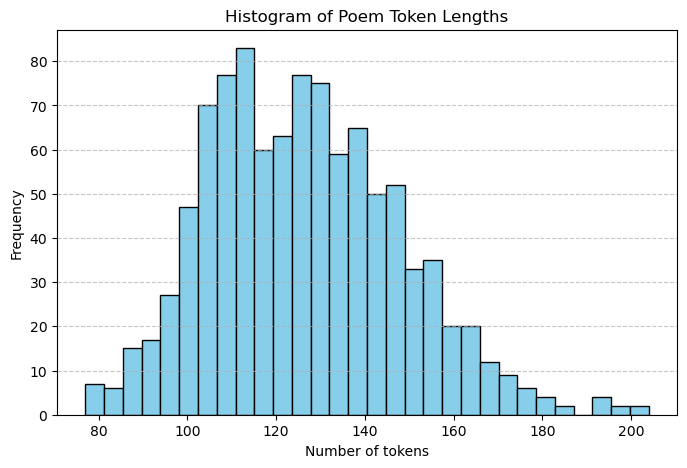

In [10]:
import matplotlib.pyplot as plt

# Calculate the length of each assistant message in messages_list
message_lengths = [len(tokenizer(messages[0]["content"])["input_ids"]) for messages in messages_list]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(message_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Poem Token Lengths')
plt.xlabel('Number of tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
# Step 4: Load configurations for QLoRA

# Load LoRA configuration
peft_config = LoraConfig(
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    r=lora_r,
    bias="none",
    task_type="CAUSAL_LM",
)

In [12]:
from transformers import TrainerCallback

class SavePerEpochCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        epoch = int(state.epoch)
        model.save_pretrained(f"{new_model}_{epoch}")
        tokenizer.save_pretrained(f"{new_model}_{epoch}")
        print(f"Saved: {new_model}_{epoch}")

save_callback = SavePerEpochCallback()

# Set training parameters
training_arguments = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    optim=optim,
    save_steps=save_steps,
    logging_steps=logging_steps,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    fp16=fp16,
    bf16=bf16,
    max_grad_norm=max_grad_norm,
    max_steps=max_steps,
    warmup_ratio=warmup_ratio,
    group_by_length=group_by_length,
    lr_scheduler_type=lr_scheduler_type,
    report_to="tensorboard",
)

# Set supervised fine-tuning parameters with proper dataset formatting
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    args=training_arguments,
    processing_class=tokenizer,
    callbacks=[save_callback],
)

# Train model
trainer.train()

# Save trained model and tokenizer together
trainer.model.save_pretrained(new_model)
tokenizer.save_pretrained(new_model)
print(f"LoRA weights and tokenizer saved to: {new_model}")

Tokenizing train dataset:   0%|          | 0/999 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/999 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
25,2.982000
50,2.009400
75,1.983500
100,1.782900
125,1.898800
150,1.700000
175,1.866200
200,1.667400
225,1.794100
250,1.675000


Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_1
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_2
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_3
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_4
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_5
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_6
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_7
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_8
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_9
Saved: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune_10
LoRA weights and tokenizer saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-finetune


# **Merge LoRA Weights with Base Model**

After training, we need to merge the LoRA weights with the base model to create a complete finetuned model.

In [13]:
# Reload model in FP16 and merge it with LoRA weights
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map=device_map,
)
model = PeftModel.from_pretrained(base_model, new_model)
model = model.merge_and_unload()

# Reload tokenizer to save it
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [14]:
# Test the merged model with a question from the training data
logging.set_verbosity(logging.CRITICAL)

print("Testing merged model:")
print("=" * 80)

# Test with a prompt from the dataset
test_sample = messages_list[0]
prompt = test_sample[0]["content"]
expected = test_sample[1]["content"]

pipe_test = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    max_length=300,
    do_sample=False,
    num_beams=1,
    temperature=1.0,
    top_k=0,
    top_p=1.0,
)
result = pipe_test(f"<s>[INST] {prompt} [/INST]")
print(f"Prompt:\n{prompt}\n")
print(f"Response:\n{result[0]['generated_text']}")
print(f"\nExpected: {expected}")
print("\n" + "=" * 80)

Testing merged model:
Prompt:
Here is a poem, what is the cifar class?

A hush in dusk, a velvet silhouette that stalks the seam of night,
silvered paws afloat the air, whispering secrets to the moon.
Whiskered compass, velvet heartbeat, eyes like distant lanterns guiding dreams,
a dancer who folds into sunbeams, then vanishes where rugs remember.

Response:
<s>[INST] Here is a poem, what is the cifar class?

A hush in dusk, a velvet silhouette that stalks the seam of night,
silvered paws afloat the air, whispering secrets to the moon.
Whiskered compass, velvet heartbeat, eyes like distant lanterns guiding dreams,
a dancer who folds into sunbeams, then vanishes where rugs remember. [/INST] Sure, the cifar class is cat 

Expected: Sure, the cifar class is cat



# **Compare Base Model vs Finetuned Model**

Load the original base model and compare its responses with the finetuned model.

In [15]:
import random

# Load a fresh base model for comparison
print("Loading base model (untrained)...")
base_model_compare = AutoModelForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map={"" : 0},
)

tokenizer_compare = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer_compare.pad_token = tokenizer_compare.eos_token
tokenizer_compare.padding_side = "right"

logging.set_verbosity(logging.CRITICAL)

# Select 10 random prompts from the dataset (no duplicates)
num_samples = min(10, len(messages_list))
random_indices = random.sample(range(len(messages_list)), num_samples)

print("\n" + "="*100)
print("COMPARISON: BASE MODEL vs FINETUNED MODEL")
print(f"Using random sample indices: {random_indices}")
print("="*100)

for idx_number, random_idx in enumerate(random_indices, 1):
    random_sample = messages_list[random_idx]
    test_prompt = random_sample[0]["content"]
    expected_response = random_sample[1]["content"]
    
    print(f"\n\nSAMPLE {idx_number} (index {random_idx})")
    print("-" * 100)
    print(f"Prompt:\n{test_prompt}")
    print("\n" + "-"*100)
    
    # Base model response (deterministic)
    print("\nBASE MODEL (Before Finetuning):")
    print("-"*100)
    pipe_base = pipeline(
        task="text-generation",
        model=base_model_compare,
        tokenizer=tokenizer_compare,
        max_length=350,
        do_sample=False,
        num_beams=1,
        temperature=1.0,
        top_k=0,
        top_p=1.0,
    )
    result_base = pipe_base(f"<s>[INST] {test_prompt} [/INST]")
    print(result_base[0]['generated_text'])
    
    # Finetuned model response
    print("\n" + "-"*100)
    print("FINETUNED MODEL (After Training):")
    print("-"*100)
    pipe_finetuned = pipeline(
        task="text-generation",
        model=model,
        tokenizer=tokenizer,
        max_length=350,
        do_sample=False,
        num_beams=1,
        temperature=1.0,
        top_k=0,
        top_p=1.0,
    )
    result_finetuned = pipe_finetuned(f"<s>[INST] {test_prompt} [/INST]")
    print(result_finetuned[0]['generated_text'])
    
    # Show expected response
    print("\n" + "-"*100)
    print("EXPECTED RESPONSE (Ground Truth):")
    print("-"*100)
    print(expected_response)
    print("\n" + "="*100)

print("\n\nComparison complete!")

Loading base model (untrained)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


COMPARISON: BASE MODEL vs FINETUNED MODEL
Using random sample indices: [654, 114, 25, 759, 281, 250, 228, 142, 754, 104]


SAMPLE 1 (index 654)
----------------------------------------------------------------------------------------------------
Prompt:
Here is a poem, what is the cifar class?

A hidden long-legged beast hums above the sighing roofs,
carving silver rivers in a bowl of dawn and thunder.
It wears a throat of cold glass, counting miles like quiet prayers,
carriages of memory drift in its wake, docking with the sun.

----------------------------------------------------------------------------------------------------

BASE MODEL (Before Finetuning):
----------------------------------------------------------------------------------------------------
<s>[INST] Here is a poem, what is the cifar class?

A hidden long-legged beast hums above the sighing roofs,
carving silver rivers in a bowl of dawn and thunder.
It wears a throat of cold glass, counting miles like quiet prayers,

KeyboardInterrupt: 